高性能混凝土非线性抗压强度预测系统 - 运行日志

>>> 模块一：加载数据集并评估特征物理贡献度...


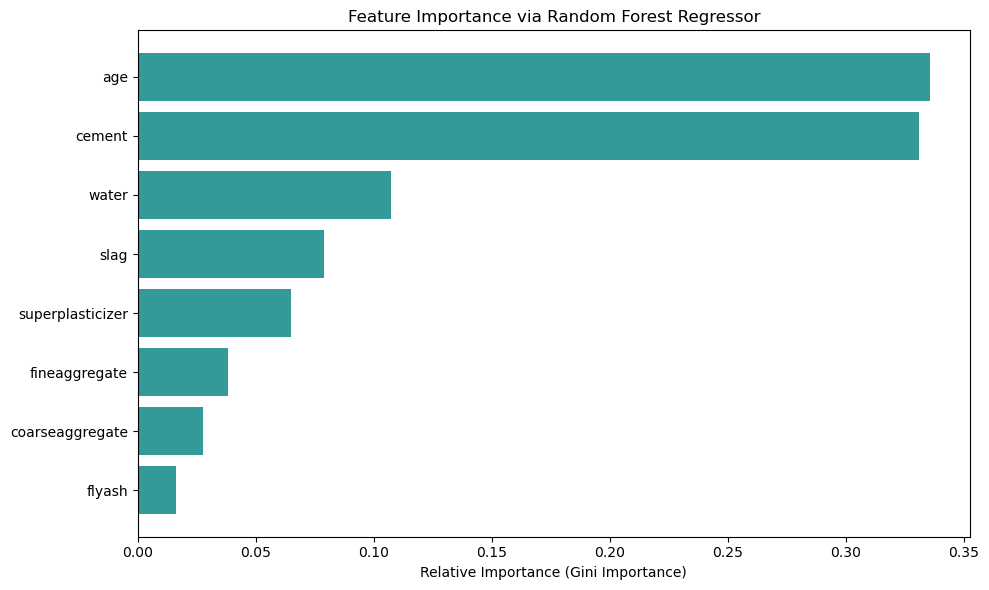

    - 特征重要性分析图已生成: 01_Feature_Importance.png

>>> 模块二：数据流形正交切分与标量化...
    - 当前计算硬件加速器: cpu

>>> 模块三：启动反向传播与泛化误差监测...
    Epoch [50/1000] | Train MSE: 40.7573 | Val MSE: 35.7791
    Epoch [100/1000] | Train MSE: 20.9471 | Val MSE: 29.0697
    Epoch [150/1000] | Train MSE: 16.5738 | Val MSE: 25.8300
    Epoch [200/1000] | Train MSE: 15.7006 | Val MSE: 25.4494

[物理截断触发] 验证集误差在连续 30 个 Epoch 内未下降。
系统过拟合临界点极小值出现在第 193 个 Epoch。训练强制终止。
    - 全局泛化极小值点权重已固化: 02_Optimal_Concrete_MLP_Weights.pth


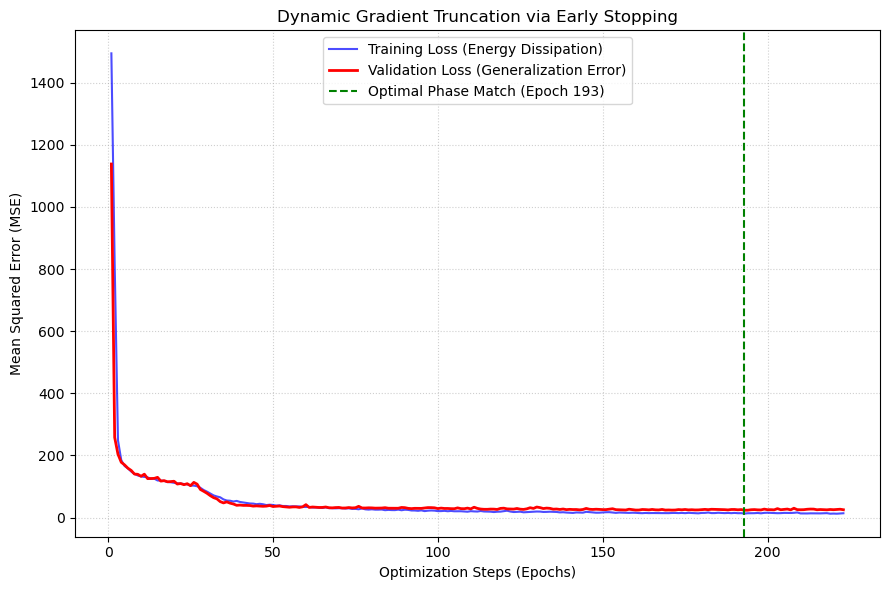


>>> 模块四：未知盲数据集泛化验证
    - 测试集 R-squared (R2): 0.8794
    - 测试集 RMSE: 5.5753 MPa


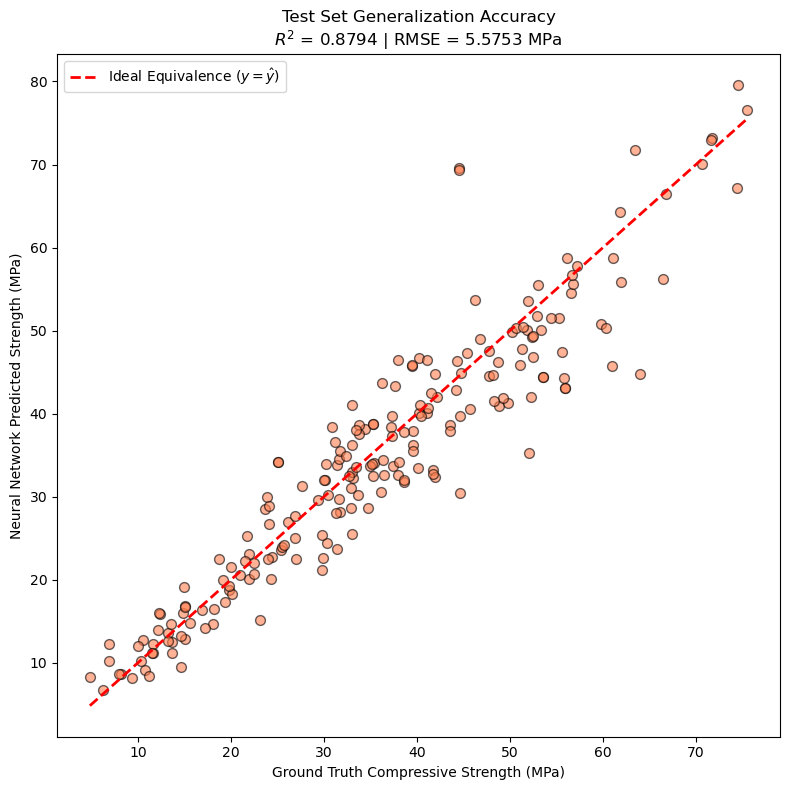


>>> 任务结束。所有运算数据与图表已保存至当前目录。日志文件: Training_Report_20260329_173407.txt


In [14]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt
import os
from datetime import datetime

# =========================================================================
# 0. 环境初始化与学术规范设定
# =========================================================================
# 绑定系统随机熵，确保非线性极化过程的严格可复现
torch.manual_seed(42)
np.random.seed(42)

# 创建日志文件指针
log_filename = f"Training_Report_{datetime.now().strftime('%Y%m%d_%H%M%S')}.txt"
def academic_print(text, end='\n'):
    """双轨输出流：同时向Notebook前端和本地磁盘写入"""
    print(text, end=end)
    with open(log_filename, 'a', encoding='utf-8') as f:
        f.write(str(text) + end)

academic_print("===" * 20)
academic_print("高性能混凝土非线性抗压强度预测系统 - 运行日志")
academic_print("===" * 20)

# =========================================================================
# 1. 泛化误差监测算子：早停机制 (Early Stopping)
# =========================================================================
class EarlyStopping:
    def __init__(self, patience=20, min_delta=1e-4):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = np.inf
        self.early_stop = False
        self.best_weights = None

    def __call__(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.best_weights = model.state_dict()
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True

# =========================================================================
# 2. 特征重要性分析与物理映射
# =========================================================================
academic_print("\n>>> 模块一：加载数据集并评估特征物理贡献度...")
df = pd.read_csv('Concrete_Data_Yeh.csv')
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values.reshape(-1, 1)
features = df.columns[:-1]

# 随机森林评估非线性重要性
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y.ravel())
importances = rf.feature_importances_

# 绘制并保存特征重要性图
plt.figure(figsize=(10, 6))
indices = np.argsort(importances)
plt.barh(range(len(indices)), importances[indices], align='center', color='teal', alpha=0.8)
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel('Relative Importance (Gini Importance)')
plt.title('Feature Importance via Random Forest Regressor')
plt.tight_layout()
plt.savefig('01_Feature_Importance.png', dpi=300, bbox_inches='tight') # 先保存
plt.show() # 后显示，释放内存
academic_print("    - 特征重要性分析图已生成: 01_Feature_Importance.png")

# =========================================================================
# 3. 数据张量流形的严格三路切分 (Train / Val / Test)
# =========================================================================
academic_print("\n>>> 模块二：数据流形正交切分与标量化...")
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.2, random_state=42)

scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled = scaler_X.transform(X_val)
X_test_scaled = scaler_X.transform(X_test)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
academic_print(f"    - 当前计算硬件加速器: {device}")

X_train_t = torch.FloatTensor(X_train_scaled).to(device)
y_train_t = torch.FloatTensor(y_train).to(device)
X_val_t = torch.FloatTensor(X_val_scaled).to(device)
y_val_t = torch.FloatTensor(y_val).to(device)
X_test_t = torch.FloatTensor(X_test_scaled).to(device)
y_test_t = torch.FloatTensor(y_test).to(device)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)

# =========================================================================
# 4. 神经网络架构与动态反向传播
# =========================================================================
academic_print("\n>>> 模块三：启动反向传播与泛化误差监测...")
model = nn.Sequential(
    nn.Linear(8, 64), nn.ReLU(),
    nn.Linear(64, 32), nn.ReLU(),
    nn.Linear(32, 1)
).to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.005)

MAX_EPOCHS = 1000 
early_stopping = EarlyStopping(patience=30, min_delta=0.01)

train_losses, val_losses = [], []
actual_epochs = 0

for epoch in range(MAX_EPOCHS):
    actual_epochs += 1
    # 训练阶段
    model.train()
    epoch_train_loss = 0
    for b_x, b_y in train_loader:
        optimizer.zero_grad()
        pred = model(b_x)
        loss = criterion(pred, b_y)
        loss.backward()
        optimizer.step()
        epoch_train_loss += loss.item()
    
    avg_train_loss = epoch_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    # 验证阶段
    model.eval()
    with torch.no_grad():
        val_pred = model(X_val_t)
        val_loss = criterion(val_pred, y_val_t).item()
        val_losses.append(val_loss)
        
    early_stopping(val_loss, model)
    
    if (epoch + 1) % 50 == 0:
         academic_print(f"    Epoch [{epoch+1}/{MAX_EPOCHS}] | Train MSE: {avg_train_loss:.4f} | Val MSE: {val_loss:.4f}")
    
    if early_stopping.early_stop:
        optimal_epoch = epoch + 1 - early_stopping.patience
        academic_print(f"\n[物理截断触发] 验证集误差在连续 {early_stopping.patience} 个 Epoch 内未下降。")
        academic_print(f"系统过拟合临界点极小值出现在第 {optimal_epoch} 个 Epoch。训练强制终止。")
        break

# 回滚权重张量
model.load_state_dict(early_stopping.best_weights)
# 保存最佳网络权重模型文件
torch.save(model.state_dict(), '02_Optimal_Concrete_MLP_Weights.pth')
academic_print("    - 全局泛化极小值点权重已固化: 02_Optimal_Concrete_MLP_Weights.pth")

# 绘制收敛曲线
plt.figure(figsize=(9, 6))
plt.plot(range(1, actual_epochs + 1), train_losses, label='Training Loss (Energy Dissipation)', color='blue', alpha=0.7)
plt.plot(range(1, actual_epochs + 1), val_losses, label='Validation Loss (Generalization Error)', color='red', linewidth=2)
plt.axvline(x=optimal_epoch, color='green', linestyle='--', label=f'Optimal Phase Match (Epoch {optimal_epoch})')
plt.xlabel('Optimization Steps (Epochs)')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Dynamic Gradient Truncation via Early Stopping')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.savefig('03_Early_Stopping_Convergence.png', dpi=300, bbox_inches='tight')
plt.show()

# =========================================================================
# 5. 宏观物理指标输出与精度评估
# =========================================================================
academic_print("\n>>> 模块四：未知盲数据集泛化验证")
model.eval()
with torch.no_grad():
    test_pred = model(X_test_t)
    test_r2 = r2_score(y_test, test_pred.cpu().numpy())
    test_rmse = np.sqrt(mean_squared_error(y_test, test_pred.cpu().numpy()))

academic_print(f"    - 测试集 R-squared (R2): {test_r2:.4f}")
academic_print(f"    - 测试集 RMSE: {test_rmse:.4f} MPa")

# 绘制预测精度散点图
plt.figure(figsize=(8, 8))
plt.scatter(y_test, test_pred.cpu().numpy(), alpha=0.6, edgecolors='k', color='coral', s=50)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Ideal Equivalence ($y=\hat{y}$)')
plt.xlabel('Ground Truth Compressive Strength (MPa)')
plt.ylabel('Neural Network Predicted Strength (MPa)')
plt.title(f'Test Set Generalization Accuracy\n$R^2$ = {test_r2:.4f} | RMSE = {test_rmse:.4f} MPa')
plt.legend()
plt.tight_layout()
plt.savefig('04_Prediction_Accuracy.png', dpi=300, bbox_inches='tight')
plt.show()

academic_print(f"\n>>> 任务结束。所有运算数据与图表已保存至当前目录。日志文件: {log_filename}")